## 1. Import des bibliotheques

In [36]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Charger les datasets

In [37]:
df_a = pd.read_csv("Arkansas/Arkansas_full_clean.csv")
df_c =pd.read_csv("california/California_combined_cleaned.csv")

## 3. Explanatory data analysis


In [38]:
#Californie
df_a.info()
df_a.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9218 entries, 0 to 9217
Columns: 364 entries, B11_T0 to crop_name
dtypes: float64(362), int64(1), object(1)
memory usage: 25.6+ MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T4,B8_T5,B8_T6,B8_T7,B8_T8,B8_T9,crop_label,latitude,longitude,crop_name
0,3758.0,4060.0,6824.0,4118.0,5594.0,5586.0,6487.0,0.0,4378.0,3828.5,...,0.0,7660.0,2674.0,3207.0,3220.0,3489.0,5,34.403047,-91.417880,Soybeans
1,3185.5,3591.5,6134.0,3803.0,6019.5,5473.0,5635.5,3500.5,2872.0,2611.0,...,0.0,8188.0,2975.0,3567.0,3024.0,2976.0,1,34.296665,-91.354877,Corn
2,3063.0,3285.5,3038.0,2816.5,2981.0,3013.5,3468.0,0.0,3210.5,3494.0,...,9956.0,4626.0,2666.0,3808.0,3793.0,3913.0,5,34.327085,-91.512739,Soybeans
3,2196.0,3534.0,5513.5,3020.0,3690.5,5059.0,6081.5,0.0,5417.0,1875.0,...,0.0,3579.0,2370.0,2834.0,3135.0,4868.0,3,35.744828,-90.708118,Rice
4,3268.0,3586.0,4803.0,3734.5,0.0,0.0,4277.0,0.0,5297.0,6177.5,...,0.0,3162.0,2406.0,0.0,3542.0,3498.0,2,35.681737,-90.577141,Cotton


In [39]:

df_c.info()
df_c.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 364 entries, B11_T0 to crop_name
dtypes: float64(362), int64(1), object(1)
memory usage: 27.8+ MB


,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,B11_T17,...,B8_T4,B8_T5,B8_T6,B8_T7,B8_T8,B8_T9,crop_label,latitude,longitude,crop_name
0,3115.0,4850.5,3541.0,3545.5,3559.0,3663.5,3795.0,3862.0,3923.5,3903.0,...,2593.0,2956.5,2476.0,3531.0,3871.0,4251.5,75,36.985456,-120.244224,Almonds
1,3010.0,4341.0,4419.5,4116.0,4093.5,4109.0,4069.0,4308.0,4304.5,4285.0,...,3169.0,3139.0,0.0,2774.0,3703.0,4121.0,69,36.806455,-120.236123,Grapes
2,5442.0,5391.5,5328.0,4944.5,4538.5,4063.0,3496.0,3168.5,2996.5,2934.0,...,3932.0,4165.0,0.0,0.0,4154.0,4314.0,54,36.593757,-120.110445,Others
3,2816.0,3150.0,2790.5,2921.5,2953.0,3062.0,3273.0,3197.0,3269.0,3260.0,...,2786.0,3115.5,3328.0,3549.5,3756.5,0.0,75,38.589882,-121.948171,Almonds
4,2606.0,3128.0,3294.5,2956.5,3423.0,3498.5,3334.5,3499.5,3542.5,3498.5,...,2212.0,2811.5,3042.0,2676.0,3034.0,3330.0,75,38.463725,-121.715547,Almonds


In [40]:
#ordonner les colonnes
nouvel_ordre = [
    'B2_T0','B3_T0','B4_T0','B5_T0','B6_T0','B7_T0','B8_T0','B8A_T0','B11_T0','B12_T0',
    'B2_T1','B3_T1','B4_T1','B5_T1','B6_T1','B7_T1','B8_T1','B8A_T1','B11_T1','B12_T1',
    'B2_T2','B3_T2','B4_T2','B5_T2','B6_T2','B7_T2','B8_T2','B8A_T2','B11_T2','B12_T2',
    'B2_T3','B3_T3','B4_T3','B5_T3','B6_T3','B7_T3','B8_T3','B8A_T3','B11_T3','B12_T3',
    'B2_T4','B3_T4','B4_T4','B5_T4','B6_T4','B7_T4','B8_T4','B8A_T4','B11_T4','B12_T4',
    'B2_T5','B3_T5','B4_T5','B5_T5','B6_T5','B7_T5','B8_T5','B8A_T5','B11_T5','B12_T5',
    'B2_T6','B3_T6','B4_T6','B5_T6','B6_T6','B7_T6','B8_T6','B8A_T6','B11_T6','B12_T6',
    'B2_T7','B3_T7','B4_T7','B5_T7','B6_T7','B7_T7','B8_T7','B8A_T7','B11_T7','B12_T7',
    'B2_T8','B3_T8','B4_T8','B5_T8','B6_T8','B7_T8','B8_T8','B8A_T8','B11_T8','B12_T8',
    'B2_T9','B3_T9','B4_T9','B5_T9','B6_T9','B7_T9','B8_T9','B8A_T9','B11_T9','B12_T9',
    'B2_T10','B3_T10','B4_T10','B5_T10','B6_T10','B7_T10','B8_T10','B8A_T10','B11_T10','B12_T10',
    'B2_T11','B3_T11','B4_T11','B5_T11','B6_T11','B7_T11','B8_T11','B8A_T11','B11_T11','B12_T11',
    'B2_T12','B3_T12','B4_T12','B5_T12','B6_T12','B7_T12','B8_T12','B8A_T12','B11_T12','B12_T12',
    'B2_T13','B3_T13','B4_T13','B5_T13','B6_T13','B7_T13','B8_T13','B8A_T13','B11_T13','B12_T13',
    'B2_T14','B3_T14','B4_T14','B5_T14','B6_T14','B7_T14','B8_T14','B8A_T14','B11_T14','B12_T14',
    'B2_T15','B3_T15','B4_T15','B5_T15','B6_T15','B7_T15','B8_T15','B8A_T15','B11_T15','B12_T15',
    'B2_T16','B3_T16','B4_T16','B5_T16','B6_T16','B7_T16','B8_T16','B8A_T16','B11_T16','B12_T16',
    'B2_T17','B3_T17','B4_T17','B5_T17','B6_T17','B7_T17','B8_T17','B8A_T17','B11_T17','B12_T17',
    'B2_T18','B3_T18','B4_T18','B5_T18','B6_T18','B7_T18','B8_T18','B8A_T18','B11_T18','B12_T18',
    'B2_T19','B3_T19','B4_T19','B5_T19','B6_T19','B7_T19','B8_T19','B8A_T19','B11_T19','B12_T19',
    'B2_T20','B3_T20','B4_T20','B5_T20','B6_T20','B7_T20','B8_T20','B8A_T20','B11_T20','B12_T20',
    'B2_T21','B3_T21','B4_T21','B5_T21','B6_T21','B7_T21','B8_T21','B8A_T21','B11_T21','B12_T21',
    'B2_T22','B3_T22','B4_T22','B5_T22','B6_T22','B7_T22','B8_T22','B8A_T22','B11_T22','B12_T22',
    'B2_T23','B3_T23','B4_T23','B5_T23','B6_T23','B7_T23','B8_T23','B8A_T23','B11_T23','B12_T23',
    'B2_T24','B3_T24','B4_T24','B5_T24','B6_T24','B7_T24','B8_T24','B8A_T24','B11_T24','B12_T24',
    'B2_T25','B3_T25','B4_T25','B5_T25','B6_T25','B7_T25','B8_T25','B8A_T25','B11_T25','B12_T25',
    'B2_T26','B3_T26','B4_T26','B5_T26','B6_T26','B7_T26','B8_T26','B8A_T26','B11_T26','B12_T26',
    'B2_T27','B3_T27','B4_T27','B5_T27','B6_T27','B7_T27','B8_T27','B8A_T27','B11_T27','B12_T27',
    'B2_T28','B3_T28','B4_T28','B5_T28','B6_T28','B7_T28','B8_T28','B8A_T28','B11_T28','B12_T28',
    'B2_T29','B3_T29','B4_T29','B5_T29','B6_T29','B7_T29','B8_T29','B8A_T29','B11_T29','B12_T29',
    'B2_T30','B3_T30','B4_T30','B5_T30','B6_T30','B7_T30','B8_T30','B8A_T30','B11_T30','B12_T30',
    'B2_T31','B3_T31','B4_T31','B5_T31','B6_T31','B7_T31','B8_T31','B8A_T31','B11_T31','B12_T31',
    'B2_T32','B3_T32','B4_T32','B5_T32','B6_T32','B7_T32','B8_T32','B8A_T32','B11_T32','B12_T32',
    'B2_T33','B3_T33','B4_T33','B5_T33','B6_T33','B7_T33','B8_T33','B8A_T33','B11_T33','B12_T33',
    'B2_T34','B3_T34','B4_T34','B5_T34','B6_T34','B7_T34','B8_T34','B8A_T34','B11_T34','B12_T34',
    'B2_T35','B3_T35','B4_T35','B5_T35','B6_T35','B7_T35','B8_T35','B8A_T35','B11_T35','B12_T35',
    'crop_label','latitude','longitude','crop_name'
]
df_a=df_a[nouvel_ordre]
df_c=df_c[nouvel_ordre]

In [41]:
df_a.head()


,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,crop_name
0,1836.0,2042.0,2412.0,2616.0,2753.0,2920.0,3186.0,3215.0,3758.0,3099.0,...,2751.0,2963.0,3288.0,3227.0,3578.0,2796.0,5,34.403047,-91.417880,Soybeans
1,1647.0,1908.0,2099.0,2438.0,2752.0,2925.5,3122.0,3092.0,3185.5,2471.0,...,2733.0,2877.0,3073.0,3093.5,2923.5,2274.0,1,34.296665,-91.354877,Corn
2,1655.0,1878.5,2135.0,2279.5,2724.5,2947.5,3587.0,3190.0,3063.0,2307.0,...,2812.0,3246.5,4146.0,3495.5,3018.5,2285.0,5,34.327085,-91.512739,Soybeans
3,1817.5,1984.0,2207.0,2458.5,2499.5,2613.0,2731.0,2754.5,2196.0,1753.5,...,2695.0,2776.5,2809.0,3044.5,2978.5,2389.0,3,35.744828,-90.708118,Rice
4,1456.0,1630.0,1704.0,2031.0,2475.0,2684.0,3062.0,2971.0,3268.0,2510.0,...,3399.0,3661.0,4022.0,3991.0,3389.0,2462.0,2,35.681737,-90.577141,Cotton


In [42]:
df_c.head()

,B2_T0,B3_T0,B4_T0,B5_T0,B6_T0,B7_T0,B8_T0,B8A_T0,B11_T0,B12_T0,...,B6_T35,B7_T35,B8_T35,B8A_T35,B11_T35,B12_T35,crop_label,latitude,longitude,crop_name
0,1588.5,1731.0,1732.0,2173.0,2406.5,2584.5,2733.0,2789.5,3115.0,2651.5,...,0.0,0.0,0.0,0.0,0.0,0.0,75,36.985456,-120.244224,Almonds
1,1776.0,1888.0,2068.0,2113.0,2184.0,2234.0,2466.0,2390.0,3010.0,2775.0,...,0.0,0.0,0.0,0.0,0.0,0.0,69,36.806455,-120.236123,Grapes
2,2597.0,2900.0,3313.0,3498.5,3519.5,3750.5,3945.0,3918.0,5442.0,5144.5,...,0.0,0.0,0.0,0.0,0.0,0.0,54,36.593757,-120.110445,Others
3,1330.0,1511.0,1778.0,1983.0,2200.0,2351.0,2489.0,2585.0,2816.0,2294.0,...,0.0,0.0,0.0,0.0,0.0,0.0,75,38.589882,-121.948171,Almonds
4,1258.0,1487.0,1587.0,1871.0,2042.0,2130.0,2226.0,2284.0,2606.0,2244.0,...,0.0,0.0,0.0,0.0,0.0,0.0,75,38.463725,-121.715547,Almonds


In [43]:
df_a['crop_name'].value_counts()



crop_name
Soybeans    4873
Rice        1743
Corn        1623
Cotton       730
Others       249
Name: count, dtype: int64

In [44]:
df_c['crop_name'].value_counts()


crop_name
Others        3054
Almonds       2839
Grapes        2080
Pistachios     927
Alfalfa        831
Rice           269
Name: count, dtype: int64

In [45]:
df_a['crop_label'].value_counts()


crop_label
5      4873
3      1743
1      1623
2       730
26       72
190      31
24       30
4        27
121      25
122      19
61       16
37        8
123       8
176       5
111       2
59        2
10        1
124       1
74        1
195       1
Name: count, dtype: int64

In [46]:
df_c['crop_label'].value_counts()


crop_label
75     2973
69     2110
204     942
24      887
36      837
54      566
76      461
3       277
6       242
1       209
72      100
2        95
28       73
21       63
77       42
66       34
4        21
42       18
23       17
68       13
67       10
22        9
43        1
Name: count, dtype: int64

In [47]:
map = folium.Map(location=[df_a['latitude'].mean(), df_a['longitude'].mean()], zoom_start=10)
for i in range(len(df_a)):
    folium.CircleMarker(
        location=[df_a.iloc[i]['latitude'],df_a.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 

In [48]:
map = folium.Map(location=[df_c['latitude'].mean(), df_c['longitude'].mean()], zoom_start=10)
for i in range(len(df_c)):
    folium.CircleMarker(
        location=[df_c.iloc[i]['latitude'],df_c.iloc[i]['longitude']],
        radius=2
    ).add_to(map)

map.save("map.html") 

# 3.Le modele

## 3.1 L'arkansas

In [25]:
print(df_a.columns.tolist())


['B2_T0', 'B3_T0', 'B4_T0', 'B5_T0', 'B6_T0', 'B7_T0', 'B8_T0', 'B8A_T0', 'B11_T0', 'B12_T0', 'B2_T1', 'B3_T1', 'B4_T1', 'B5_T1', 'B6_T1', 'B7_T1', 'B8_T1', 'B8A_T1', 'B11_T1', 'B12_T1', 'B2_T2', 'B3_T2', 'B4_T2', 'B5_T2', 'B6_T2', 'B7_T2', 'B8_T2', 'B8A_T2', 'B11_T2', 'B12_T2', 'B2_T3', 'B3_T3', 'B4_T3', 'B5_T3', 'B6_T3', 'B7_T3', 'B8_T3', 'B8A_T3', 'B11_T3', 'B12_T3', 'B2_T4', 'B3_T4', 'B4_T4', 'B5_T4', 'B6_T4', 'B7_T4', 'B8_T4', 'B8A_T4', 'B11_T4', 'B12_T4', 'B2_T5', 'B3_T5', 'B4_T5', 'B5_T5', 'B6_T5', 'B7_T5', 'B8_T5', 'B8A_T5', 'B11_T5', 'B12_T5', 'B2_T6', 'B3_T6', 'B4_T6', 'B5_T6', 'B6_T6', 'B7_T6', 'B8_T6', 'B8A_T6', 'B11_T6', 'B12_T6', 'B2_T7', 'B3_T7', 'B4_T7', 'B5_T7', 'B6_T7', 'B7_T7', 'B8_T7', 'B8A_T7', 'B11_T7', 'B12_T7', 'B2_T8', 'B3_T8', 'B4_T8', 'B5_T8', 'B6_T8', 'B7_T8', 'B8_T8', 'B8A_T8', 'B11_T8', 'B12_T8', 'B2_T9', 'B3_T9', 'B4_T9', 'B5_T9', 'B6_T9', 'B7_T9', 'B8_T9', 'B8A_T9', 'B11_T9', 'B12_T9', 'B2_T10', 'B3_T10', 'B4_T10', 'B5_T10', 'B6_T10', 'B7_T10', 'B8_T10',

In [26]:
#separer x et y
df_a_x = df_a.drop(columns=['crop_label','latitude','longitude','crop_name'])
X_a = df_a_x.values
df_a_y =df_a[['crop_name','crop_label']]
df_a_y.loc[df_a['crop_name'] == 'Others', 'crop_label'] = 0
df_a_y.loc[df_a['crop_label'] == 5, 'crop_label'] = 4
y_a = df_a_y['crop_label'].values

In [27]:
#reshape
X_a = X_a.reshape(-1,36,10)  

#normalisation
X_a = X_a / np.max(X_a)

In [28]:
mask = (X_a != 0).astype(float)


In [29]:
# separer le dataset en :une partie pour entrainer et valider et une partie pour tester le modele
X_a_train, X_a_test, y_a_train, y_a_test, mask_a_train, mask_a_test = train_test_split(
    X_a, y_a, mask, test_size=0.15, random_state=42
)

In [55]:
#Le CNN
def CNNBlock(x):
    shortcut = x
    
    x = layers.Conv1D(filters=x.shape[-1], kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters=x.shape[-1], kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])  #shortcut 
    x = layers.ReLU()(x)

    return x

In [56]:
#Transformer
def TransformerBlock(x, num_heads=5):
    dim = x.shape[-1]

    # Multi-head attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Feed Forward
    ff = layers.Dense(dim, activation='relu')(x)
    ff = layers.Dense(dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x

In [57]:
def ALPE(x, mask):
    

    x = layers.Multiply()([x, mask])

    x = layers.Conv1D(filters=x.shape[-1], kernel_size=3, padding='same')(x)

    # Attention simple (approximation ECA)
    weights = layers.GlobalAveragePooling1D()(x)
    weights = layers.Dense(x.shape[-1], activation='sigmoid')(weights)
    weights = layers.Reshape((1, x.shape[-1]))(weights)

    x = layers.Multiply()([x, weights])

    return x

In [58]:
def CTFusion(x):
    cnn_out = CNNBlock(x)
    trans_out = TransformerBlock(x)

    return layers.Add()([cnn_out, trans_out])

In [59]:
def build_MCTNet(input_shape=(36, 10), num_classes=5):
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    
    x = ALPE(inputs, mask)

   
    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)

   
    x = layers.GlobalMaxPooling1D()(x)

    # Classifier
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=[inputs, mask], outputs=outputs)

    return model

In [60]:
model = build_MCTNet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 36, 10)    │          0 │ input_layer_2[0]… │
│ (Multiply)          │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 36, 10)    │        310 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │        110 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 10)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 36, 10)    │          0 │ conv1d_1[0][0],   │
│ (Multiply)          │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 36, 10)    │        310 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ multiply_2[0][0], │
│ (MultiHeadAttentio… │                   │            │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 36, 10)    │         40 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 36, 10)    │          0 │ multiply_2[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 36, 10)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 36, 10)    │         20 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 36, 10)    │        310 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 36, 10)    │        110 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 36, 10)    │          0 │ batch_normalizat… │
│                     │                   │            │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,835 (38.42 KB)

 Trainable params: 9,715 (37.95 KB)

 Non-trainable params: 120 (480.00 B)

In [ ]:
model.fit(
    [X_a_train, mask_a_train],
    y_a_train,
    validation_data=([X_a_test, mask_a_test], y_a_test),
    epochs=200,
    batch_size=32
)

In [ ]:
y_a_pred = model.predict([X_a_test, mask_a_test])
y_a_pred = y_a_pred.argmax(axis=1)

oa = accuracy_score(y_a_test, y_a_pred)
f1 = f1_score(y_a_test, y_a_pred, average='macro')
kappa = cohen_kappa_score(y_a_test, y_a_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)

In [ ]:
# Confusion Matrix 
labels = ["Soybeans", "Rice", "Cotton", "Corn", "Others"]
cm = confusion_matrix(y_a_test, y_a_pred,labels=[4,3,2,1,0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

In [ ]:
#3.2 CALIFORNIA

In [49]:
print(df_c.columns.tolist())


['B2_T0', 'B3_T0', 'B4_T0', 'B5_T0', 'B6_T0', 'B7_T0', 'B8_T0', 'B8A_T0', 'B11_T0', 'B12_T0', 'B2_T1', 'B3_T1', 'B4_T1', 'B5_T1', 'B6_T1', 'B7_T1', 'B8_T1', 'B8A_T1', 'B11_T1', 'B12_T1', 'B2_T2', 'B3_T2', 'B4_T2', 'B5_T2', 'B6_T2', 'B7_T2', 'B8_T2', 'B8A_T2', 'B11_T2', 'B12_T2', 'B2_T3', 'B3_T3', 'B4_T3', 'B5_T3', 'B6_T3', 'B7_T3', 'B8_T3', 'B8A_T3', 'B11_T3', 'B12_T3', 'B2_T4', 'B3_T4', 'B4_T4', 'B5_T4', 'B6_T4', 'B7_T4', 'B8_T4', 'B8A_T4', 'B11_T4', 'B12_T4', 'B2_T5', 'B3_T5', 'B4_T5', 'B5_T5', 'B6_T5', 'B7_T5', 'B8_T5', 'B8A_T5', 'B11_T5', 'B12_T5', 'B2_T6', 'B3_T6', 'B4_T6', 'B5_T6', 'B6_T6', 'B7_T6', 'B8_T6', 'B8A_T6', 'B11_T6', 'B12_T6', 'B2_T7', 'B3_T7', 'B4_T7', 'B5_T7', 'B6_T7', 'B7_T7', 'B8_T7', 'B8A_T7', 'B11_T7', 'B12_T7', 'B2_T8', 'B3_T8', 'B4_T8', 'B5_T8', 'B6_T8', 'B7_T8', 'B8_T8', 'B8A_T8', 'B11_T8', 'B12_T8', 'B2_T9', 'B3_T9', 'B4_T9', 'B5_T9', 'B6_T9', 'B7_T9', 'B8_T9', 'B8A_T9', 'B11_T9', 'B12_T9', 'B2_T10', 'B3_T10', 'B4_T10', 'B5_T10', 'B6_T10', 'B7_T10', 'B8_T10',

In [100]:
X_c = df_c.drop(columns=['crop_label','latitude','longitude','crop_name']).values

df_c_y = df_c[['crop_label']].copy()

keep = [3, 36, 69, 75, 204]

# tout le reste → 0
df_c_y['crop_label'] = df_c_y['crop_label'].apply(lambda x: x if x in keep else 0)

# remap
df_c_y['crop_label'] = df_c_y['crop_label'].replace({
    3: 1,
    36: 2,
    69: 3,
    75: 4,
    204: 5
})

y_c = df_c_y['crop_label'].values

print(sorted(np.unique(y_c)))



[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [101]:
#reshape
X_c = X_c.reshape(-1,36,10)  

#normalisation
X_c = X_c / np.max(X_c)

In [102]:
mask = (X_c != 0).astype(float)


In [103]:
# separer le dataset en :une partie pour entrainer et valider et une partie pour tester le modele
X_c_train, X_c_test, y_c_train, y_c_test, mask_c_train, mask_c_test = train_test_split(
    X_c, y_c, mask, test_size=0.15, random_state=42
)

In [104]:
def build_MCTNet_c(input_shape=(36, 10), num_classes=6):
    inputs = tf.keras.Input(shape=input_shape)
    mask = tf.keras.Input(shape=input_shape)

    
    x = ALPE(inputs, mask)

   
    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)

   
    x = layers.GlobalMaxPooling1D()(x)

    # Classifier
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_c = tf.keras.Model(inputs=[inputs, mask], outputs=outputs)

    return model_c

In [105]:
model_c = build_MCTNet_c()

model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_c.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_13         │ (None, 36, 10)    │          0 │ input_layer_14[0… │
│ (Multiply)          │                   │            │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_13[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_43[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 10)        │        110 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 10)     │          0 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_14         │ (None, 36, 10)    │          0 │ conv1d_43[0][0],  │
│ (Multiply)          │                   │            │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 36, 10)    │        310 │ multiply_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ multiply_14[0][0… │
│ (MultiHeadAttentio… │                   │            │ multiply_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_73 (Add)        │ (None, 36, 10)    │          0 │ multiply_14[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 36, 10)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_73[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_45 (Conv1D)  │ (None, 36, 10)    │        310 │ re_lu_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 36, 10)    │        110 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_45[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 36, 10)    │        110 │ dense_49[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_72 (Add)        │ (None, 36, 10)    │          0 │ batch_normalizat… │
│                     │                   │            │ multiply_14[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,846 (38.46 KB)

 Trainable params: 9,726 (37.99 KB)

 Non-trainable params: 120 (480.00 B)

In [106]:
model_c.fit(
    [X_c_train, mask_c_train],
    y_c_train,
    validation_data=([X_c_test, mask_c_test], y_c_test),
    epochs=200,
    batch_size=32
)

Epoch 1/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.4655 - loss: 1.5814 - val_accuracy: 0.3020 - val_loss: 1.7557
Epoch 2/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.6180 - loss: 1.0467 - val_accuracy: 0.5020 - val_loss: 1.3688
Epoch 3/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6636 - loss: 0.9291 - val_accuracy: 0.6047 - val_loss: 1.0736
Epoch 4/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.6949 - loss: 0.8586 - val_accuracy: 0.6500 - val_loss: 0.9605
Epoch 5/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7060 - loss: 0.8197 - val_accuracy: 0.6027 - val_loss: 1.0830
Epoch 6/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7221 - loss: 0.7784 - val_accuracy: 0.6760 - val_loss: 0.8892
Epoch 7/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7289 - loss: 0.7559 - val_accuracy: 0.6213 - val_loss: 1.0165
Epoch 8/200
266/266 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.7327 - loss: 0.7345

In [111]:
y_c_pred = model_c.predict([X_c_test, mask_c_test])
y_c_pred = y_c_pred.argmax(axis=1)

oa = accuracy_score(y_c_test, y_c_pred)
f1 = f1_score(y_c_test, y_c_pred, average='macro')
kappa = cohen_kappa_score(y_c_test, y_c_pred)

print("OA:", oa)
print("F1:", f1)
print("Kappa:", kappa)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
OA: 0.7193333333333334
F1: 0.7370354760888143
Kappa: 0.635462275973818


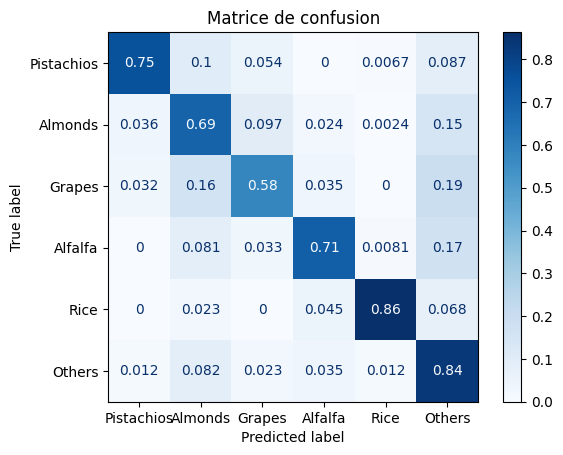

In [112]:
# Confusion Matrix 
labels = ["Pistachios","Almonds","Grapes", "Alfalfa","Rice", "Others"]
cm_c = confusion_matrix(y_c_test, y_c_pred,labels=[5,4,3,2,1,0])
cm_norm_c = cm_c.astype(float) / cm_c.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c,display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.show()